## Inwiefern führt die Stuktur von Wikidata zu einer Unterrepräsentation alltäglicher Berufe und welche geschlechtsspezifischen Verzerrungen  ergeben sich daraus?

#### Einleitung

In dieser Analyse wird untersucht, wie Männer und Frauen in verschiedenen Berufsgruppen auf Wikidata repräsentiert werden. Dabei soll analysiert werden, ob bestimmte Berufe geschlechtsspezifisch verzerrt dargestellt werden.

Besonders interessant ist die Frage, ob statusorientierte Berufe wie Politiker, CEOs oder Ärzte stärker männlich dominiert sind als soziale oder alltägliche Berufe wie Pflegefachkräfte oder Erzieher.

Zusätzlich werden die Wikidata-Ergebnisse mit realen Arbeitsmarktdaten verglichen, um mögliche Unterschiede zwischen digitaler Repräsentation und gesellschaftlicher Realität sichtbar zu machen.

#### Methodik

Für die Analyse wurden Daten aus Wikidata zu verschiedenen Berufsgruppen gesammelt. Anschließend wurde die Geschlechterverteilung innerhalb der Berufe visualisiert.

Die ausgewählten Berufe umfassen sowohl statusorientierte Berufe als auch soziale bzw. alltägliche Berufe. Dadurch kann untersucht werden, ob bestimmte Berufsgruppen auf Wikidata unterschiedlich dargestellt werden.

Die Analyse und Visualisierung erfolgte mit Python, Pandas, NumPy und Matplotlib.

## Geschlechterverteilung innerhalb ausgewählter Berufe

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

In [51]:
pfad = "../data"

aerzte = pd.read_csv(os.path.join(pfad, "aerzte_wikidata.csv"))
beamte = pd.read_csv(os.path.join(pfad, "beamte_wikidata.csv"))
buero = pd.read_csv(os.path.join(pfad, "bueroangestellte_wikidata.csv"))
ceo = pd.read_csv(os.path.join(pfad, "ceo_wikidata.csv"))
erzieher = pd.read_csv(os.path.join(pfad, "erzieher_wikidata.csv"))
lehrer = pd.read_csv(os.path.join(pfad, "lehrer_wikidata.csv"))
pflege = pd.read_csv(os.path.join(pfad, "pflegefachkraft_wikidata.csv"))
politiker = pd.read_csv(os.path.join(pfad, "politiker_wikidata.csv"))

In [52]:
aerzte["beruf"] = "Ärzte"
beamte["beruf"] = "Beamte"
buero["beruf"] = "Büroangestellte"
ceo["beruf"] = "CEO"
erzieher["beruf"] = "Erzieher"
lehrer["beruf"] = "Lehrer"
pflege["beruf"] = "Pflegefachkräfte"
politiker["beruf"] = "Politiker"

In [53]:
alle_berufe = pd.concat([
    aerzte,
    pflege,
    ceo,
    buero,
    lehrer,
    erzieher,
    politiker,
    beamte
])


In [54]:
gesamt_pro_beruf = alle_berufe.groupby("beruf")["count"].transform("sum")

alle_berufe["anteil_prozent"] = (
    alle_berufe["count"] / gesamt_pro_beruf * 100
).round(2)

alle_berufe

,genderLabel,count,beruf,anteil_prozent
0,männlich,5222,Ärzte,91.71
1,weiblich,472,Ärzte,8.29
0,weiblich,208,Pflegefachkräfte,79.69
1,männlich,53,Pflegefachkräfte,20.31
0,männlich,103,CEO,91.96
1,weiblich,9,CEO,8.04
0,weiblich,7,Büroangestellte,53.85
1,männlich,6,Büroangestellte,46.15
0,männlich,3589,Lehrer,78.69
1,weiblich,972,Lehrer,21.31


In [55]:
plot_df = alle_berufe[
    alle_berufe["genderLabel"].isin(["männlich", "weiblich"])
]

In [56]:
plot_df = alle_berufe[
    alle_berufe["genderLabel"].isin(["männlich", "weiblich"])
]

statusberufe = plot_df[
    plot_df["beruf"].isin([
        "CEO",
        "Ärzte",
        "Beamte",
        "Politiker"
    ])
]

pivot_status = statusberufe.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_status

genderLabel,männlich,weiblich
beruf,,
Beamte,96.99,3.01
CEO,91.96,8.04
Politiker,85.16,14.84
Ärzte,91.71,8.29


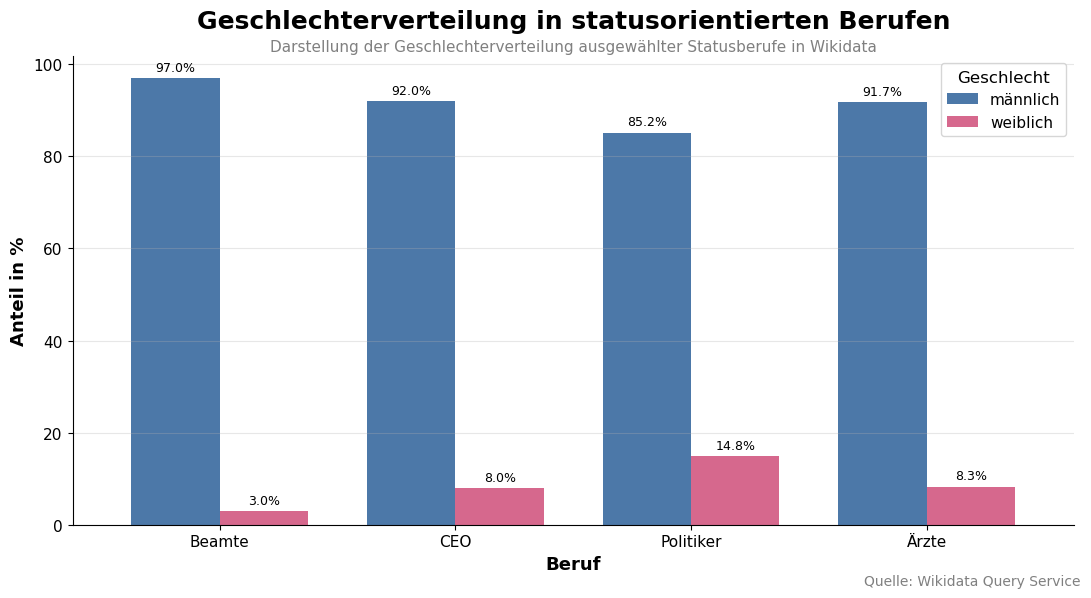

In [57]:
# Farben festlegen
farbe_maenner = "#4C78A8"   # blau
farbe_frauen = "#D6688D"    # pink

pivot_status.plot(
    kind="bar",
    figsize=(11,6),
    color=[farbe_maenner, farbe_frauen],
    width=0.75
)

# Titel
plt.title(
    "Geschlechterverteilung in statusorientierten Berufen",
    fontsize=18,
    fontweight="bold",
    loc="center",
    pad=20
)

# Untertitel
plt.text(
    0.5,
    1.01,
    "Darstellung der Geschlechterverteilung ausgewählter Statusberufe in Wikidata",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray",
    ha="center"
)

# Achsen
plt.ylabel("Anteil in %", fontweight="bold")
plt.xlabel("Beruf", fontweight="bold")

plt.xticks(rotation=0)

# Gridlines
plt.grid(axis="y", alpha=0.3)

# Clean Style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legende
plt.legend(title="Geschlecht")

# Prozentwerte über Balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# Quelle unten rechts
plt.figtext(
    0.99,
    0.01,
    "Quelle: Wikidata Query Service",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

### Interpretation

Die Grafik zeigt, dass statusorientierte Berufe auf Wikidata überwiegend männlich dargestellt werden. Besonders bei Beamten, CEOs und Politikern ist der Männeranteil deutlich höher als der Frauenanteil.

Dies deutet darauf hin, dass Personen mit gesellschaftlicher Macht, Sichtbarkeit oder historischer Bedeutung häufiger männlich sind oder zumindest häufiger in Wikidata erfasst werden.

In [58]:
alltagsberufe = plot_df[
    plot_df["beruf"].isin([
        "Büroangestellte",
        "Erzieher",
        "Lehrer",
        "Pflegefachkräfte"
    ])
]

pivot_alltag = alltagsberufe.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_alltag

genderLabel,männlich,weiblich
beruf,,
Büroangestellte,46.15,53.85
Erzieher,46.15,53.85
Lehrer,78.69,21.31
Pflegefachkräfte,20.31,79.69


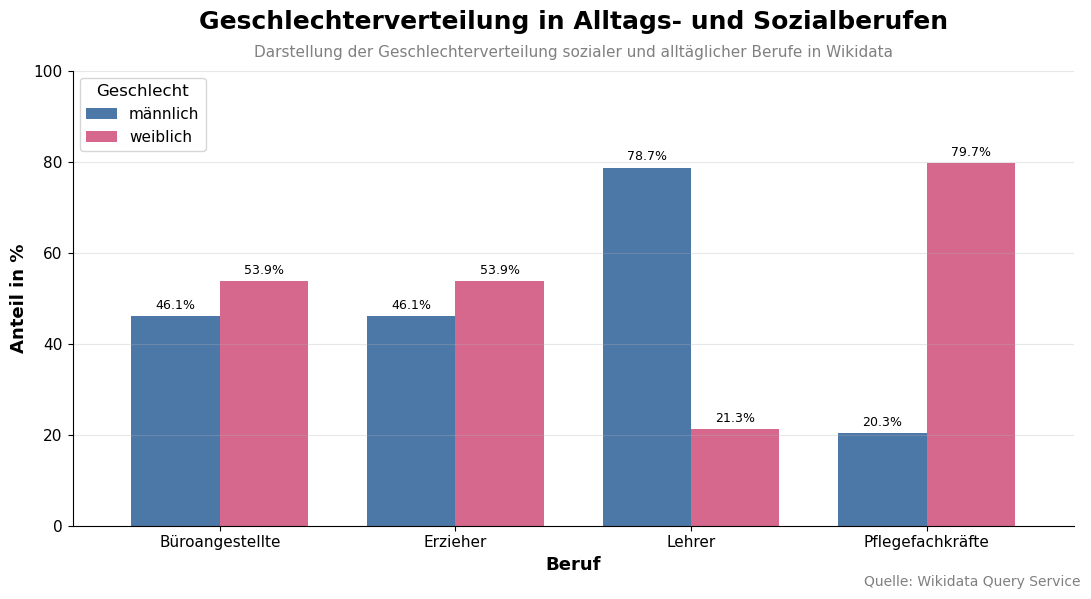

In [59]:
# Farben festlegen
farbe_maenner = "#4C78A8"   # blau
farbe_frauen = "#D6688D"    # pink

pivot_alltag.plot(
    kind="bar",
    figsize=(11,6),
    color=[farbe_maenner, farbe_frauen],
    width=0.75
)

# Titel
plt.title(
    "Geschlechterverteilung in Alltags- und Sozialberufen",
    fontsize=18,
    fontweight="bold",
    loc="center",
    pad=30
)

# Untertitel
plt.text(
    0.5,
    1.03,
    "Darstellung der Geschlechterverteilung sozialer und alltäglicher Berufe in Wikidata",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray",
    ha="center"
)

# Achsen
plt.ylabel("Anteil in %", fontweight="bold")
plt.xlabel("Beruf", fontweight="bold")

plt.xticks(rotation=0)

# Gridlines
plt.grid(axis="y", alpha=0.3)

# Clean Style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legende
plt.legend(title="Geschlecht")

# y-Achse immer von 0 bis 100 Prozent
plt.ylim(0, 100)

# Prozentwerte über Balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# Quelle unten rechts
plt.figtext(
    0.99,
    0.01,
    "Quelle: Wikidata Query Service",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

### Interpretation

Die Grafik zeigt deutliche Unterschiede zwischen den untersuchten Berufsgruppen. Während Pflegefachkräfte und teilweise Erzieher stärker weiblich geprägt sind, erscheinen Lehrer auf Wikidata überraschend männlich dominiert.

Dies zeigt, dass Wikidata die reale Berufsstruktur nicht vollständig abbildet, sondern vor allem Personen enthält, die als relevant genug für einen Eintrag gelten.

## Vergleich mit realen Arbeitsmarktdaten

Im folgenden Abschnitt wird die Geschlechterverteilung in Wikidata mit realen Arbeitsmarktdaten verglichen. Dadurch soll untersucht werden, ob bestimmte Berufsgruppen auf Wikidata stärker männlich oder weiblich dargestellt werden als in der Realität.

In [60]:
aerzte_real = pd.read_csv(
    os.path.join(pfad, "aerzte_reale_daten.csv")
)

beamte_real = pd.read_csv(
    os.path.join(pfad, "beamte_reale_daten.csv")
)

buero_real = pd.read_csv(
    os.path.join(pfad, "bueroangestellte_reale_daten.csv")
)

ceo_real = pd.read_csv(
    os.path.join(pfad, "ceo_reale_daten.csv")
)

erzieher_real = pd.read_csv(
    os.path.join(pfad, "erzieher_reale_daten.csv")
)

lehrer_real = pd.read_csv(
    os.path.join(pfad, "lehrer_reale_daten.csv")
)

pflege_real = pd.read_csv(
    os.path.join(pfad, "pflegefachkraft_reale_daten.csv")
)

politiker_real = pd.read_csv(
    os.path.join(pfad, "politiker_reale_daten.csv")
)

In [61]:
aerzte_real["beruf"] = "Ärzte"
beamte_real["beruf"] = "Beamte"
buero_real["beruf"] = "Büroangestellte"
ceo_real["beruf"] = "CEO"
erzieher_real["beruf"] = "Erzieher"
lehrer_real["beruf"] = "Lehrer"
pflege_real["beruf"] = "Pflegefachkräfte"
politiker_real["beruf"] = "Politiker"

In [62]:
reale_daten = pd.concat([
    aerzte_real,
    beamte_real,
    buero_real,
    ceo_real,
    erzieher_real,
    lehrer_real,
    pflege_real,
    politiker_real
])

reale_daten = reale_daten.rename(
    columns={
        "count": "anteil_prozent"
    }
)

reale_daten

,genderLabel,anteil_prozent,beruf
0,männlich,49.77,Ärzte
1,weiblich,50.23,Ärzte
0,männlich,45.45,Beamte
1,weiblich,54.55,Beamte
0,männlich,34.40,Büroangestellte
1,weiblich,65.60,Büroangestellte
0,männlich,71.05,CEO
1,weiblich,28.95,CEO
0,männlich,8.10,Erzieher
1,weiblich,91.90,Erzieher


In [63]:
statusberufe_real = reale_daten[
    reale_daten["beruf"].isin([
        "CEO",
        "Ärzte",
        "Beamte",
        "Politiker"
    ])
]

pivot_status_real = statusberufe_real.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_status_real

genderLabel,männlich,weiblich
beruf,,
Beamte,45.45,54.55
CEO,71.05,28.95
Politiker,68.00,32.00
Ärzte,49.77,50.23


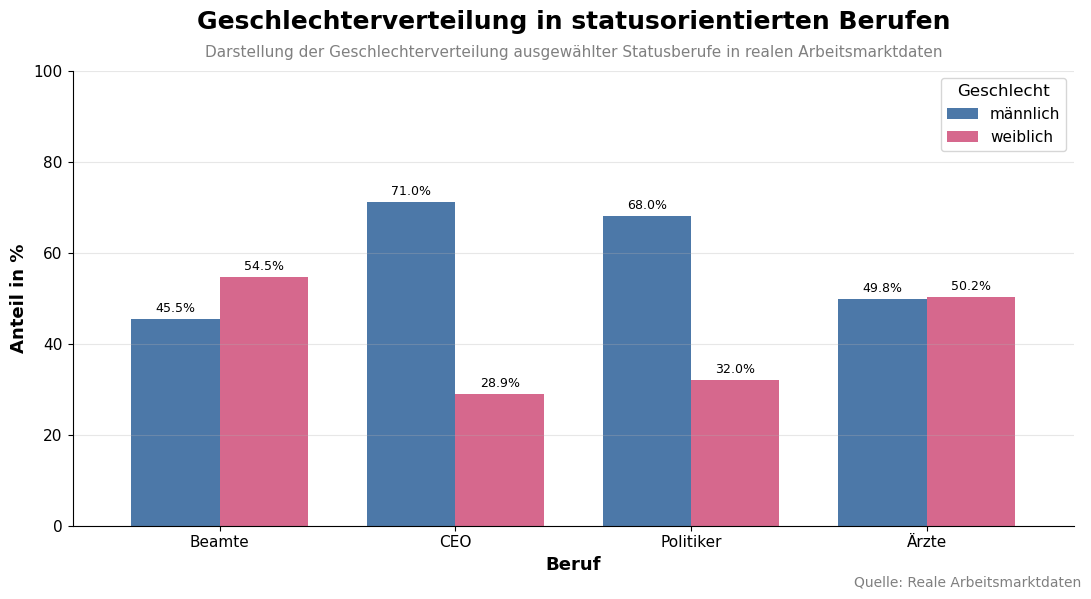

In [64]:
# Farben festlegen
farbe_maenner = "#4C78A8"   # blau
farbe_frauen = "#D6688D"    # pink

pivot_status_real.plot(
    kind="bar",
    figsize=(11,6),
    color=[farbe_maenner, farbe_frauen],
    width=0.75
)

# Titel
plt.title(
    "Geschlechterverteilung in statusorientierten Berufen",
    fontsize=18,
    fontweight="bold",
    loc="center",
    pad=30
)

# Untertitel
plt.text(
    0.5,
    1.03,
    "Darstellung der Geschlechterverteilung ausgewählter Statusberufe in realen Arbeitsmarktdaten",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray",
    ha="center"
)

# Achsen
plt.ylabel("Anteil in %", fontweight="bold")
plt.xlabel("Beruf", fontweight="bold")

plt.xticks(rotation=0)

# Gridlines
plt.grid(axis="y", alpha=0.3)

# Clean Style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legende
plt.legend(title="Geschlecht")

# y-Achse immer von 0 bis 100 Prozent
plt.ylim(0, 100)

# Prozentwerte über Balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# Quelle unten rechts
plt.figtext(
    0.99,
    0.01,
    "Quelle: Reale Arbeitsmarktdaten",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

In [65]:
alltagsberufe_real = reale_daten[
    reale_daten["beruf"].isin([
        "Büroangestellte",
        "Erzieher",
        "Lehrer",
        "Pflegefachkräfte"
    ])
]

pivot_alltag_real = alltagsberufe_real.pivot(
    index="beruf",
    columns="genderLabel",
    values="anteil_prozent"
)

pivot_alltag_real

genderLabel,männlich,weiblich
beruf,,
Büroangestellte,34.4,65.6
Erzieher,8.1,91.9
Lehrer,13.8,86.2
Pflegefachkräfte,22.0,78.0


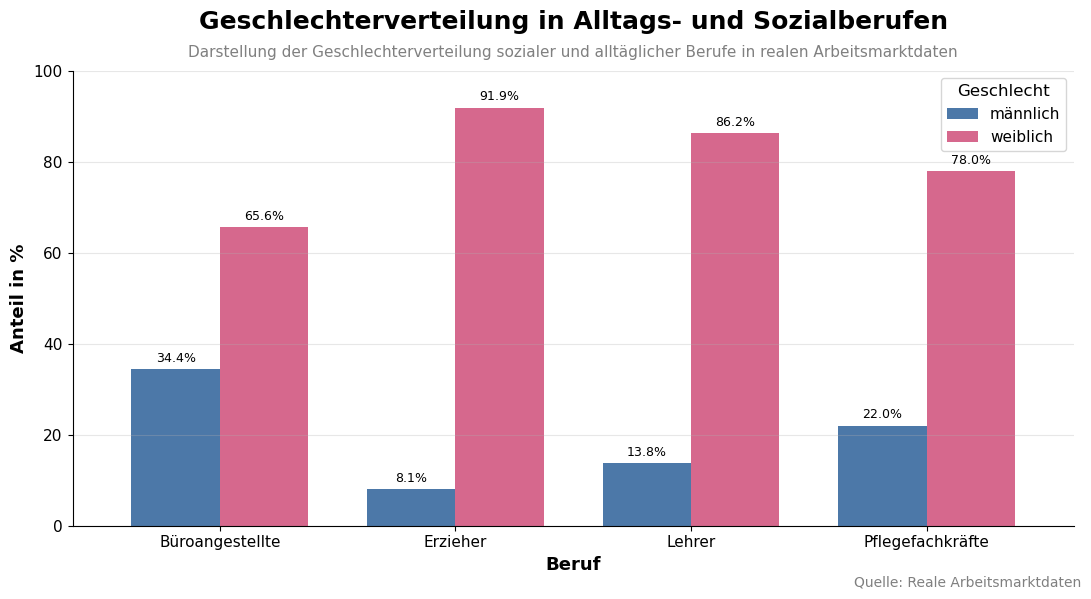

In [66]:
# Farben festlegen
farbe_maenner = "#4C78A8"   # blau
farbe_frauen = "#D6688D"    # pink

pivot_alltag_real.plot(
    kind="bar",
    figsize=(11,6),
    color=[farbe_maenner, farbe_frauen],
    width=0.75
)

# Titel
plt.title(
    "Geschlechterverteilung in Alltags- und Sozialberufen",
    fontsize=18,
    fontweight="bold",
    loc="center",
    pad=30
)

# Untertitel
plt.text(
    0.5,
    1.03,
    "Darstellung der Geschlechterverteilung sozialer und alltäglicher Berufe in realen Arbeitsmarktdaten",
    transform=plt.gca().transAxes,
    fontsize=11,
    color="gray",
    ha="center"
)

# Achsen
plt.ylabel("Anteil in %", fontweight="bold")
plt.xlabel("Beruf", fontweight="bold")

plt.xticks(rotation=0)

# Gridlines
plt.grid(axis="y", alpha=0.3)

# Clean Style
ax = plt.gca()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Legende
plt.legend(title="Geschlecht")

# y-Achse immer von 0 bis 100 Prozent
plt.ylim(0, 100)

# Prozentwerte über Balken
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.1f%%",
        padding=3,
        fontsize=9
    )

# Quelle unten rechts
plt.figtext(
    0.99,
    0.01,
    "Quelle: Reale Arbeitsmarktdaten",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

Der Vergleich mit realen Arbeitsmarktdaten zeigt, dass Wikidata die tatsächliche Geschlechterverteilung in mehreren Berufen nicht realistisch abbildet. Besonders große Abweichungen zeigen sich bei Lehrern, Beamten, Ärzten und Erziehern. Dies deutet darauf hin, dass Wikidata nicht die heutige Berufsrealität darstellt, sondern vor allem Personen erfasst, die historisch oder gesellschaftlich als relevant gelten.

In [67]:
wikidata_frauen = alle_berufe[
    alle_berufe["genderLabel"] == "weiblich"
][["beruf", "anteil_prozent"]]

wikidata_frauen = wikidata_frauen.rename(
    columns={
        "anteil_prozent": "wikidata"
    }
)

real_frauen = reale_daten[
    reale_daten["genderLabel"] == "weiblich"
][["beruf", "anteil_prozent"]]

real_frauen = real_frauen.rename(
    columns={
        "anteil_prozent": "real"
    }
)

In [68]:
vergleich = pd.merge(
    wikidata_frauen,
    real_frauen,
    on="beruf"
)

vergleich

,beruf,wikidata,real
0,Ärzte,8.29,50.23
1,Pflegefachkräfte,79.69,78.00
2,CEO,8.04,28.95
3,Büroangestellte,53.85,65.60
4,Lehrer,21.31,86.20
5,Erzieher,53.85,91.90
6,Politiker,14.84,32.00
7,Beamte,3.01,54.55


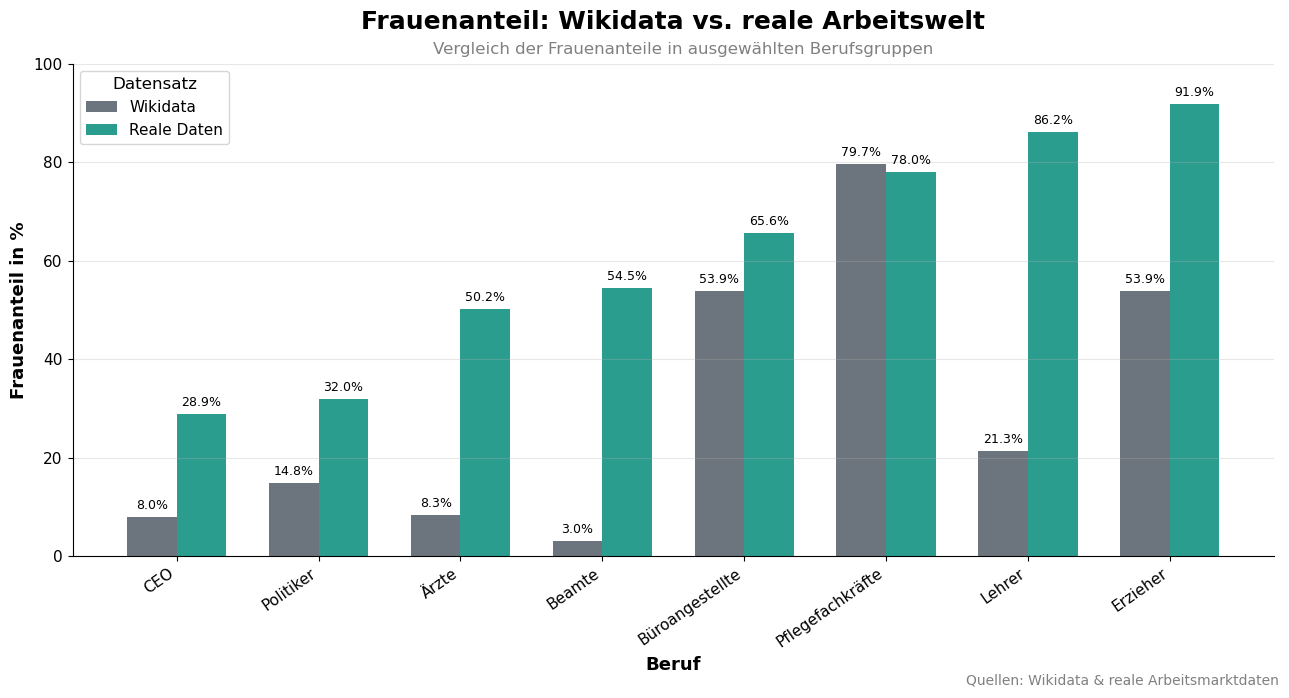

In [69]:
vergleich_sorted = vergleich.sort_values("real")

x = np.arange(len(vergleich_sorted["beruf"]))
breite = 0.35

fig, ax = plt.subplots(figsize=(13,7))

# Neue Farben:
farbe_wikidata = "#6C757D"   # grau
farbe_real = "#2A9D8F"       # türkis/grün

bars1 = ax.bar(
    x - breite/2,
    vergleich_sorted["wikidata"],
    breite,
    label="Wikidata",
    color=farbe_wikidata
)

bars2 = ax.bar(
    x + breite/2,
    vergleich_sorted["real"],
    breite,
    label="Reale Daten",
    color=farbe_real
)

# Titel
ax.set_title(
    "Frauenanteil: Wikidata vs. reale Arbeitswelt",
    loc="center",
    pad=25
)

# Untertitel
ax.text(
    0.3,
    1.02,
    "Vergleich der Frauenanteile in ausgewählten Berufsgruppen",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
)

# Achsen
ax.set_ylabel("Frauenanteil in %")
ax.set_xlabel("Beruf")

ax.set_xticks(x)

ax.set_xticklabels(
    vergleich_sorted["beruf"],
    rotation=35,
    ha="right"
)

ax.set_ylim(0,100)

# Grid
ax.grid(axis="y", alpha=0.3)

# Clean Style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Werte über Balken
for bars in [bars1, bars2]:
    for bar in bars:
        hoehe = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            hoehe + 1,
            f"{hoehe:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

# Legende
ax.legend(title="Datensatz")

# Quelle unten rechts
fig.text(
    0.99,
    0.01,
    "Quellen: Wikidata & reale Arbeitsmarktdaten",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

In [70]:
wikidata_maenner = alle_berufe[
    alle_berufe["genderLabel"] == "männlich"
][["beruf", "anteil_prozent"]]

wikidata_maenner = wikidata_maenner.rename(
    columns={
        "anteil_prozent": "wikidata"
    }
)

real_maenner = reale_daten[
    reale_daten["genderLabel"] == "männlich"
][["beruf", "anteil_prozent"]]

real_maenner = real_maenner.rename(
    columns={
        "anteil_prozent": "real"
    }
)

vergleich_maenner = pd.merge(
    wikidata_maenner,
    real_maenner,
    on="beruf"
)

vergleich_maenner

,beruf,wikidata,real
0,Ärzte,91.71,49.77
1,Pflegefachkräfte,20.31,22.00
2,CEO,91.96,71.05
3,Büroangestellte,46.15,34.40
4,Lehrer,78.69,13.80
5,Erzieher,46.15,8.10
6,Politiker,85.16,68.00
7,Beamte,96.99,45.45


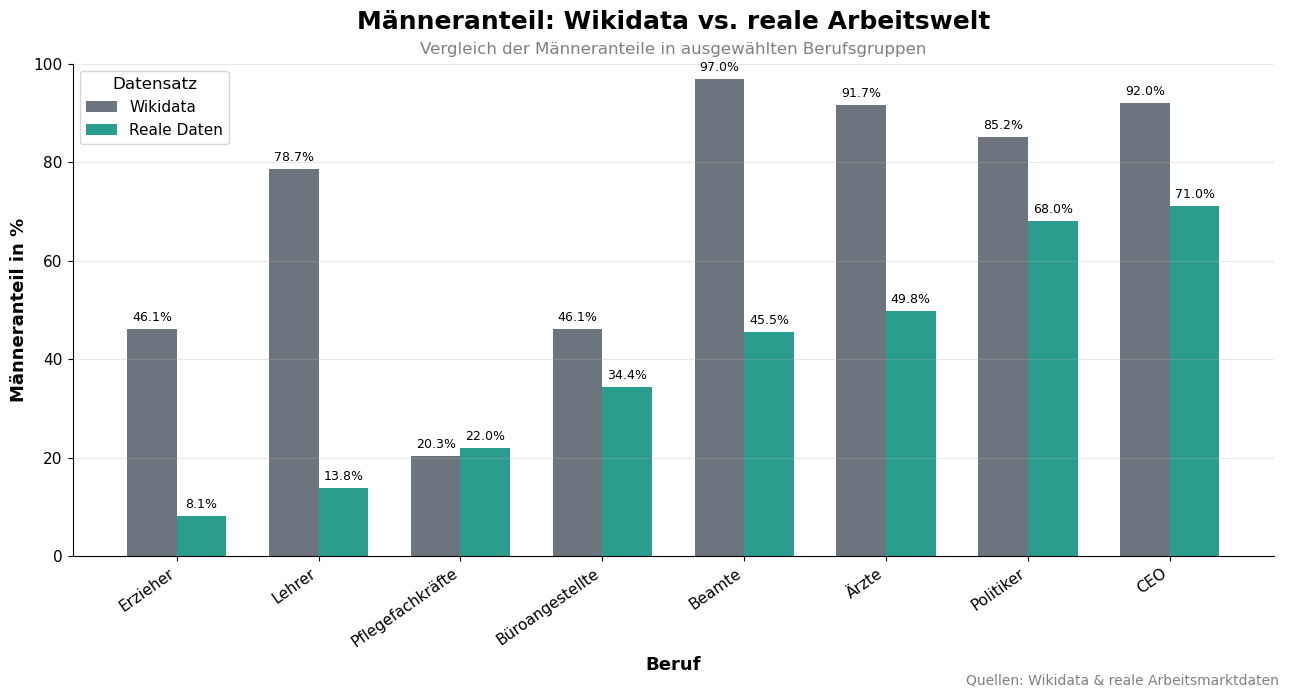

In [73]:
vergleich_maenner_sorted = vergleich_maenner.sort_values("real")

x = np.arange(len(vergleich_maenner_sorted["beruf"]))
breite = 0.35

fig, ax = plt.subplots(figsize=(13,7))

farbe_wikidata = "#6C757D"   # grau
farbe_real = "#2A9D8F"       # türkis/grün

bars1 = ax.bar(
    x - breite/2,
    vergleich_maenner_sorted["wikidata"],
    breite,
    label="Wikidata",
    color=farbe_wikidata
)

bars2 = ax.bar(
    x + breite/2,
    vergleich_maenner_sorted["real"],
    breite,
    label="Reale Daten",
    color=farbe_real
)

ax.set_title(
    "Männeranteil: Wikidata vs. reale Arbeitswelt",
    loc="center",
    pad=25,
    fontweight="bold"
)

ax.text(
    0.5,
    1.02,
    "Vergleich der Männeranteile in ausgewählten Berufsgruppen",
    transform=ax.transAxes,
    fontsize=12,
    color="gray",
    ha="center"
)

ax.set_ylabel("Männeranteil in %", fontweight="bold")
ax.set_xlabel("Beruf", fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(
    vergleich_maenner_sorted["beruf"],
    rotation=35,
    ha="right"
)

ax.set_ylim(0,100)
ax.grid(axis="y", alpha=0.3)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

for bars in [bars1, bars2]:
    for bar in bars:
        hoehe = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width()/2,
            hoehe + 1,
            f"{hoehe:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9
        )

ax.legend(title="Datensatz")

fig.text(
    0.99,
    0.01,
    "Quellen: Wikidata & reale Arbeitsmarktdaten",
    ha="right",
    fontsize=10,
    color="gray"
)

plt.tight_layout()
plt.show()

## Interpretation

Die Ergebnisse zeigen, dass Männer in mehreren Berufen auf Wikidata deutlich stärker vertreten sind als in der realen Arbeitswelt. Besonders auffällig ist dies bei Lehrern, Beamten und Ärzten.

Dadurch wird sichtbar, dass Wikidata nicht nur gesellschaftliche Realität abbildet, sondern auch bestehende Sichtbarkeits- und Relevanzstrukturen verstärken kann.

## Fazit

Die Analyse zeigt, dass Wikidata die reale Geschlechterverteilung in mehreren Berufsgruppen nur eingeschränkt widerspiegelt. Besonders statusorientierte Berufe werden deutlich männlicher dargestellt als in realen Arbeitsmarktdaten.

Gleichzeitig sind soziale und alltägliche Berufe teilweise unterrepräsentiert oder verzerrt dargestellt. Dies deutet darauf hin, dass gesellschaftliche Sichtbarkeit, historische Relevanz und öffentliche Aufmerksamkeit einen starken Einfluss darauf haben, welche Personen in Wikidata erfasst werden.

Die Ergebnisse zeigen somit, dass digitale Wissensplattformen wie Wikidata bestehende gesellschaftliche Ungleichheiten nicht nur widerspiegeln, sondern teilweise auch verstärken können.

## Quellen

- Wikidata
- ...
- Python Libraries: pandas, numpy, matplotlib